1: **Description of the Failure Scenario
Failure Scenario** :

A Massive Data Outlier (Exploding Gradient)
In this experiment, I will simulate a scenario where the dataset contains a massive, unscaled outlier. I expect AdaGrad to completely fail and stop learning the moment it hits this outlier. Because AdaGrad continuously adds the square of every past gradient into a running total, a single massive error will permanently inflate that total. This will cause the algorithm's learning rate to instantly shrink to near-zero, effectively paralyzing the model for the rest of the training process.

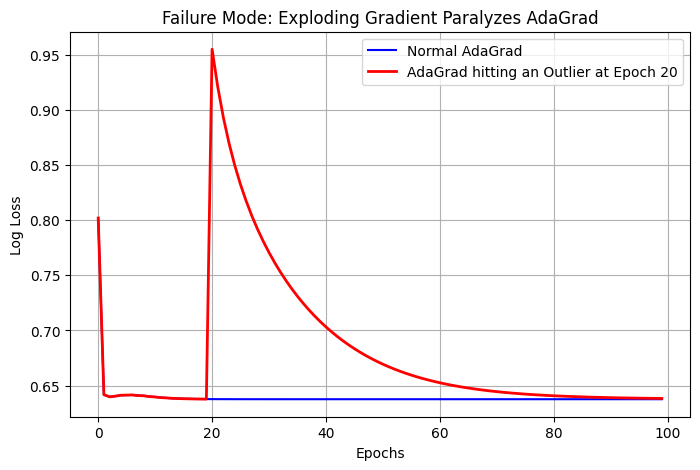

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

dataset = pd.read_csv("sparse_toy_dataset.csv")
X = dataset.drop("target", axis=1).values
y = dataset["target"].values
X = np.c_[np.ones(X.shape[0]), X]


def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

def compute_gradient(X_batch, y_batch, weights):
    predictions = sigmoid(np.dot(X_batch, weights))
    return np.dot(X_batch.T, (predictions - y_batch)) / len(y_batch)

def compute_loss(X_batch, y_batch, weights):
    predictions = sigmoid(np.dot(X_batch, weights))
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    return -np.mean(y_batch * np.log(predictions) + (1 - y_batch) * np.log(1 - predictions))


def train_adagrad_failure(X, y, epochs=100, eta=0.5, delta=1e-8):
    weights = np.zeros(X.shape[1])
    sum_sq_gradients = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        gradient = compute_gradient(X, y, weights)


        if epoch == 20:
            gradient = gradient * 1000

        sum_sq_gradients += gradient ** 2
        H_t = np.sqrt(sum_sq_gradients) + delta
        weights -= (eta / H_t) * gradient


        loss_history.append(compute_loss(X, y, weights))

    return weights, loss_history


_, failure_loss = train_adagrad_failure(X, y)


def train_adagrad_normal(X, y, epochs=100, eta=0.5, delta=1e-8):
    weights = np.zeros(X.shape[1])
    sum_sq_gradients = np.zeros(X.shape[1])
    loss_history = []
    for epoch in range(epochs):
        gradient = compute_gradient(X, y, weights)
        sum_sq_gradients += gradient ** 2
        H_t = np.sqrt(sum_sq_gradients) + delta
        weights -= (eta / H_t) * gradient
        loss_history.append(compute_loss(X, y, weights))
    return weights, loss_history

_, normal_loss = train_adagrad_normal(X, y)


plt.figure(figsize=(8, 5))
plt.plot(normal_loss, label="Normal AdaGrad", color="blue")
plt.plot(failure_loss, label="AdaGrad hitting an Outlier at Epoch 20", color="red", linewidth=2)
plt.title("Failure Mode: Exploding Gradient Paralyzes AdaGrad")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)


plt.show()

**Explanation of the Failure**

When the model saw a very large unusual data point (outlier) at epoch 20, the training loss suddenly stopped improving and became flat.


This happened because of the way AdaGrad adjusts its learning rate.


AdaGrad calculates the learning rate by dividing the base learning rate by the square root of the sum of all past squared gradients.


When the huge outlier appeared, the gradient suddenly became about 1000 times larger than normal. Because AdaGrad stores and keeps adding all past gradients, this very large value made the total sum extremely large.


The important problem is that this sum can only increase and never decrease.

Because of this:

The denominator in the formula became very large

The learning rate became extremely small (almost zero)

When the learning rate became almost zero, the model could no longer update its weights properly. In simple words, the model stopped learning and became stuck.

It is like trying to move a car but the engine power suddenly becomes almost zero.

This problem also breaks Assumption 3 from Task 1.2, which says that the gradients should stay within reasonable limits and should not become extremely large.

**Suggested Modification**

To fix this problem, we can change the way AdaGrad remembers past gradients.

Instead of storing all gradients forever, the algorithm can use an exponentially decaying moving average of the squared gradients.

This means:

Older gradients slowly fade away

The model can forget very old or extreme values

Because of this, if a huge outlier appears, its effect will reduce over time, and the learning rate can recover back to normal.

So the model will be able to continue learning instead of getting stuck.